## Model Selection and Experimental Approach

This notebook addresses the task of **semantic similarity between text pairs** using models adapted for text-regression-style prediction.

Two main language-model architectures are considered: a **decoder-only model**, GPT-2, and an **encoder model**, BERT.

For each architecture, two encoding strategies are implemented:

- **Bi-encoder**
- **Cross-encoder**

These combinations produce four experimental approaches:

1. GPT-2 with a **bi-encoder** architecture  
2. GPT-2 with a **cross-encoder** architecture  
3. BERT with a **bi-encoder** architecture  
4. BERT with a **cross-encoder** architecture


In [ ]:
%%capture
!pip install pytorch-lightning

In [ ]:
# Python estándar
import pandas as pd
import numpy as np
from IPython.display import clear_output, display

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# PyTorch Lightning
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# Hugging Face Transformers & Datasets
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
from datasets import load_dataset, Dataset, DatasetDict
from sentence_transformers import SentenceTransformer, util

# Estadística
from scipy.stats import pearsonr, linregress

# Visualización
import matplotlib.pyplot as plt

## Dataset and DataModule for the Bi-Encoder


In [ ]:
# =================================
# Dataset STS - Bi-Encoder
# =================================
class STSDataset(Dataset):
    """
    Conversion to a list:
        The Hugging Face dataset implements its own __getitems__ method, which
        intercepts index-based access before __getitem__ is reached and causes
        indexing errors with PyTorch's DataLoader. To avoid this, I materialized
        the dataset as a Python list and disabled Hugging Face's __getitems__.

    Label normalization:
        The original dataset scores are in the [0, 5] range. I transformed them
        to [-1, 1] using (score / 2.5) - 1 so they align with the output range
        of cosine similarity, which the Bi-Encoder uses to compare embeddings.
    """
    def __init__(self, dataset):
        self.samples = list(dataset)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        score = item["score"]
        if isinstance(score, list):
            score = score[0]
        label = (score / 2.5) - 1
        return {
            "text1": item["sentence1"],
            "text2": item["sentence2"],
            "labels": torch.tensor(label, dtype=torch.float)
        }

    __getitems__ = None


# =================================
# Collate function
# =================================
def make_bi_collate_fn(tokenizer):
    """
    Create a collate function for PyTorch's DataLoader.
    Tokenization is performed here at full-batch level instead of inside
    __getitem__.
    This enables dynamic padding: each batch is padded only up to the length of
    the longest sequence it contains, rather than up to a fixed maximum. This is
    more efficient than tokenizing sentence by sentence.
    """
    def bi_collate_fn(batch):
        batch_text1 = [item["text1"] for item in batch]
        batch_text2 = [item["text2"] for item in batch]
        batch_labels = torch.stack([item["labels"] for item in batch])
        enc1 = tokenizer(batch_text1, padding=True, truncation=True, max_length=128, return_tensors="pt")
        enc2 = tokenizer(batch_text2, padding=True, truncation=True, max_length=128, return_tensors="pt")
        return {
            "input_ids1": enc1["input_ids"],
            "attention_mask1": enc1["attention_mask"],
            "input_ids2": enc2["input_ids"],
            "attention_mask2": enc2["attention_mask"],
            "labels": batch_labels
        }
    return bi_collate_fn


# =================================
# DataModule Lightning - Bi-Encoder
# =================================
class STSDataModule(pl.LightningDataModule):
    """
    This creates the training and validation DataLoaders, receiving the
    tokenizer as a parameter so the module is compatible with either model used
    in this exercise: GPT-2 and BERT.

    The training DataLoader applies shuffling to prevent the model from learning
    the order of the examples. The validation DataLoader does not shuffle, so
    results remain reproducible across epochs.
    """
    def __init__(self, train_dataset, val_dataset, tokenizer, batch_size=16, num_workers=2):
        super().__init__()
        self.train_dataset_raw = train_dataset
        self.val_dataset_raw = val_dataset
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_dataset = STSDataset(self.train_dataset_raw)
        self.val_dataset = STSDataset(self.val_dataset_raw)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, batch_size=self.batch_size, shuffle=True,
            num_workers=self.num_workers, collate_fn=make_bi_collate_fn(self.tokenizer)
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, collate_fn=make_bi_collate_fn(self.tokenizer)
        )

## Lightning Module: Bi-Encoder


In [ ]:
# =============================
# LightningModule: BiEncoderSTS
# =============================
class BiEncoderSTS(pl.LightningModule):
    """

    Architecture:
        Unlike a Cross-Encoder, the Bi-Encoder encodes the two sentences
        independently, producing one embedding per sentence. Similarity is
        computed by comparing both embeddings with cosine similarity.

    Pooling:
        To obtain each sentence embedding, I applied mean pooling over the token
        embeddings from the last hidden layer. This averages all tokens weighted
        by the attention mask, producing a more robust representation than using
        only the [CLS] token. It is also compatible with GPT-2, which does not
        include a [CLS] token.

    Metrics:
        In on_validation_epoch_end, predictions and labels from all batches in
        the epoch are accumulated before computing Pearson r. Computing it on an
        individual batch of 16 samples would produce an unstable result.

    Optimization:
        AdamW is used with OneCycleLR, which applies a gradual learning-rate
        warmup during the first 10% of training and then decays it. This
        stabilizes fine-tuning for pre-trained models such as BERT, which are
        sensitive to high learning rates at the start.
    """
    def __init__(self, model_name="bert-base-uncased", lr=2e-5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.lr = lr
        self.loss_fn = nn.MSELoss()
        self._val_preds = []
        self._val_labels = []

    def mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        summed = torch.sum(token_embeddings * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def encode(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.mean_pooling(outputs, attention_mask)

    def forward(self, batch):
        emb1 = self.encode(batch["input_ids1"], batch["attention_mask1"])
        emb2 = self.encode(batch["input_ids2"], batch["attention_mask2"])
        sim = F.cosine_similarity(emb1, emb2)
        return sim

    def training_step(self, batch, batch_idx):
        preds = self(batch)
        labels = batch["labels"]
        loss = self.loss_fn(preds, labels)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        preds = self(batch)
        labels = batch["labels"]
        loss = self.loss_fn(preds, labels)
        self.log("val_loss", loss, prog_bar=True)
        self._val_preds.append(preds.detach().cpu())
        self._val_labels.append(labels.detach().cpu())
        return preds, labels

    def on_validation_epoch_end(self):
        if not self._val_preds:
            return
        preds = torch.cat(self._val_preds).numpy()
        labels = torch.cat(self._val_labels).numpy()
        pearson, _ = pearsonr(preds, labels)
        self.log("val_pearson", float(pearson), prog_bar=True)
        self._val_preds.clear()
        self._val_labels.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=0.01)
        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = int(0.1 * total_steps)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.lr,
            total_steps=total_steps,
            pct_start=warmup_steps / total_steps,
            anneal_strategy="cos"
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"}
        }

In [ ]:
class LiveMetricsSTSCallback(pl.Callback):
    def __init__(self, figsize=(12,4), update_freq=1):
        """
        Callback that dynamically plots the loss and validation Pearson
        coefficient at the end of each epoch.
        """

        super().__init__()
        self.figsize = figsize
        self.update_freq = update_freq

        self.metrics = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "val_pearson": []
        }

        self.fig = None
        self.axes = None
        self.lines = {}
        self.initialized = False

        self.val_preds = []
        self.val_labels = []

    def _to_number(self, value):
        try:
            return float(value.item())
        except Exception:
            try:
                return float(value)
            except Exception:
                return np.nan

    def on_train_start(self, trainer, pl_module):
        self._initialize_plot()

    def _initialize_plot(self):
        if self.initialized:
            return
        self.fig, self.axes = plt.subplots(1, 2, figsize=self.figsize)
        titles = ["Loss (train vs val)", "Validation Pearson"]
        ylabels = ["Loss", "r"]
        for ax, t, y in zip(self.axes, titles, ylabels):
            ax.set_title(t, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(y)
            ax.grid(True, alpha=0.3)
            self.lines[t] = {}
            if t == "Loss (train vs val)":
                line_train, = ax.plot([], [], label="train_loss", color="blue", marker="o")
                line_val, = ax.plot([], [], label="val_loss", color="orange", marker="o")
                ax.legend()
                self.lines[t]["train"] = line_train
                self.lines[t]["val"] = line_val
            elif t == "Validation Pearson":
                line, = ax.plot([], [], label="val_pearson", color="green", marker="o")
                ax.legend()
                self.lines[t]["val"] = line
        plt.tight_layout()
        self.initialized = True

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = int(trainer.current_epoch)
        metrics = trainer.callback_metrics
        self.metrics["epoch"].append(epoch)
        self.metrics["train_loss"].append(self._to_number(metrics.get("train_loss", np.nan)))
        if epoch % self.update_freq == 0:
            self._update_plot()

    def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, dataloader_idx=0):
        if trainer.sanity_checking:
            return
        preds, labels = outputs
        self.val_preds.extend(preds.detach().cpu().numpy())
        self.val_labels.extend(labels.detach().cpu().numpy())
    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        metrics = trainer.callback_metrics
        self.metrics["val_loss"].append(self._to_number(metrics.get("val_loss", np.nan)))
        self.metrics["val_pearson"].append(self._to_number(metrics.get("val_pearson", np.nan)))
        self.val_preds = []
        self.val_labels = []


    def _update_plot(self):
        if not self.initialized or not self.metrics["epoch"]:
            return

        epochs = self.metrics["epoch"]

        def pad(lst):
            while len(lst) < len(epochs):
                lst.append(np.nan)

        pad(self.metrics["val_loss"])
        pad(self.metrics["val_pearson"])

        # Loss
        ax_lines = self.lines["Loss (train vs val)"]
        self._set_line(ax_lines["train"], epochs, np.array(self.metrics["train_loss"], dtype=float))
        self._set_line(ax_lines["val"], epochs, np.array(self.metrics["val_loss"], dtype=float))
        # Pearson
        ax_lines = self.lines["Validation Pearson"]
        self._set_line(ax_lines["val"], epochs, np.array(self.metrics["val_pearson"], dtype=float))

        clear_output(wait=True)
        display(self.fig)
        plt.pause(0.001)

    @staticmethod
    def _set_line(line, epochs, series):
        if len(epochs) == 0 or series.size == 0:
            line.set_data([], [])
            return
        valid_mask = ~np.isnan(series)
        xs = [epochs[i] for i in range(len(epochs)) if valid_mask[i]]
        ys = [series[i] for i in range(len(series)) if valid_mask[i]]
        line.set_data(xs, ys)
        if len(xs) > 0:
            line.axes.relim()
            line.axes.autoscale_view()

    def save_plot(self, filepath="sts_training_metrics.png", dpi=300):
        if self.fig is not None:
            self.fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
            print(f"Plot saved to {filepath}")

# Train BERT Bi-Encoder


In [ ]:

ds = load_dataset("mteb/stsbenchmark-sts", "default")


tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
data_module_bert = STSDataModule(ds["train"], ds["validation"], tokenizer=tokenizer_bert)


data_module_bert.setup()
model_bi_bert = BiEncoderSTS("bert-base-uncased")
bi_bert_logger= LiveMetricsSTSCallback()

checkpoint_callback = ModelCheckpoint(
    dirpath="/content/checkpoints/bi-bert",
    monitor="val_pearson",
    mode="max",
    save_top_k=1,
    filename="best-bi-bert-{epoch:02d}-{val_pearson:.4f}",
    verbose=True,
    save_weights_only=False,
)

early_stop = EarlyStopping(
    monitor="val_pearson",
    patience=3,
    mode="max",
    verbose=True
)

data_module_bert.prepare_data()
data_module_bert.setup()

README.md: 0.00B [00:00, ?B/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

validation.jsonl.gz:   0%|          | 0.00/86.4k [00:00<?, ?B/s]

test.jsonl.gz:   0%|          | 0.00/63.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


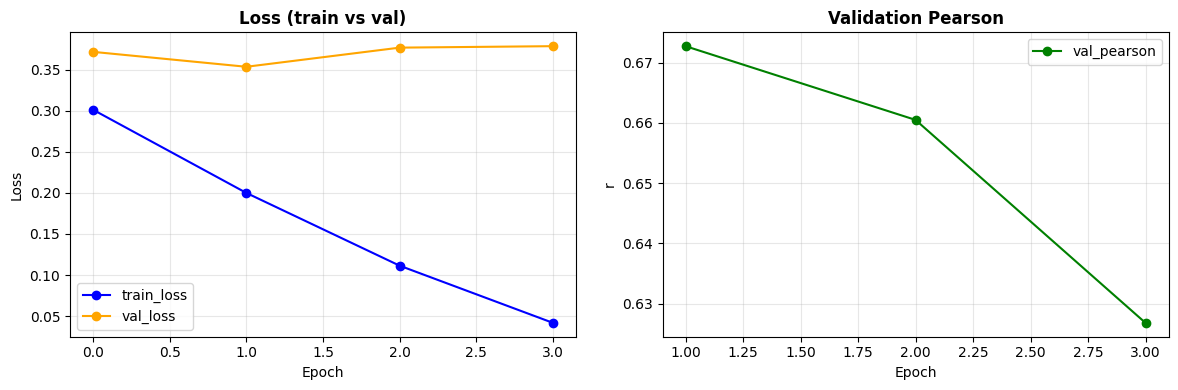

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_pearson did not improve in the last 3 records. Best score: 0.673. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 3, global step 1440: 'val_pearson' was not in top 1


In [ ]:
trainer_bi_bert = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    callbacks=[bi_bert_logger, checkpoint_callback, early_stop]
)

trainer_bi_bert.fit(model_bi_bert, datamodule=data_module_bert)

# Train GPT-2 Bi-Encoder


In [ ]:
model_bi_gpt2 = BiEncoderSTS("gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


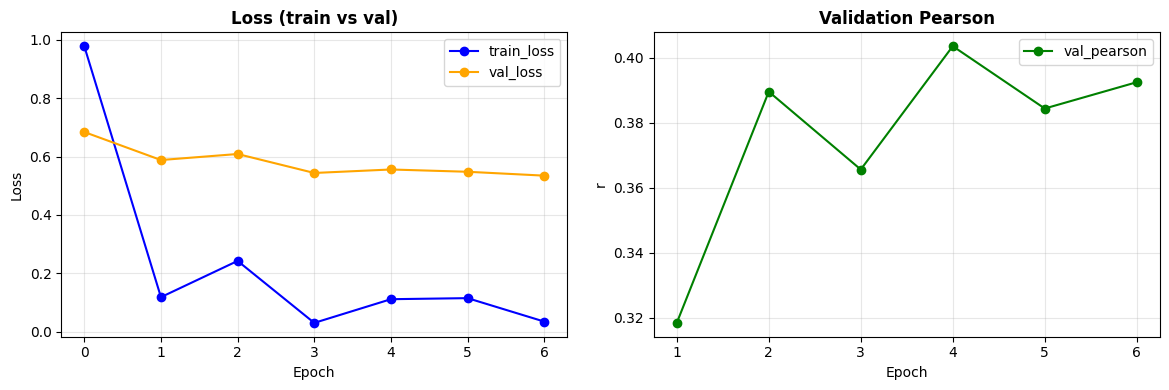

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_pearson did not improve in the last 3 records. Best score: 0.404. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 6, global step 2520: 'val_pearson' was not in top 1


In [ ]:
ds = load_dataset("mteb/stsbenchmark-sts", "default")


tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")
tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token
data_module_gpt2 = STSDataModule(ds["train"], ds["validation"], tokenizer=tokenizer_gpt2)

model_bi_gpt2 = BiEncoderSTS("gpt2")
bi_gpt2_logger = LiveMetricsSTSCallback()

checkpoint_callback = ModelCheckpoint(
    dirpath="/content/checkpoints/bi-gpt2",
    monitor="val_pearson",
    mode="max",
    save_top_k=1,
    filename="best-bi-gpt2-{epoch:02d}-{val_pearson:.4f}",
    verbose=True,
    save_weights_only=False,
)

early_stop = EarlyStopping(
    monitor="val_pearson",
    patience=3,
    mode="max",
    verbose=True
)

trainer_bi_gpt2 = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    callbacks=[bi_gpt2_logger, checkpoint_callback, early_stop]
)

trainer_bi_gpt2.fit(model_bi_gpt2, datamodule=data_module_gpt2)

In [ ]:
def predict_similarity(model, tokenizer, sentence1, sentence2, max_length=128, device=None):
    """
    Run inference with a fine-tuned Bi-Encoder and return the semantic
    similarity between two sentences on the STSBenchmark [0, 5] scale.

    Scale conversion:
        The model returns cosine similarity in [-1, 1]. During training, labels
        were normalized from [0, 5] to [-1, 1] (as mentioned earlier in the
        DataModule docstring), so this function reverses that transformation:
        (sim + 1) / 2 * 5 to recover the original scale.

    Note: This function was implemented earlier for comparing sentences with
        bi-encoder models. In the final version, however, only the cross-encoder
        prediction function is used, since that model achieved stronger
        performance.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # Tokenize the sentences separately
    enc1 = tokenizer(sentence1, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    enc2 = tokenizer(sentence2, padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")

    batch = {
        "input_ids1": enc1["input_ids"].to(device),
        "attention_mask1": enc1["attention_mask"].to(device),
        "input_ids2": enc2["input_ids"].to(device),
        "attention_mask2": enc2["attention_mask"].to(device)
    }

    with torch.no_grad():
        sim = model(batch)  # Cosine similarity (-1,1)

    # Normalize to [0, 1]
    sim_norm = (sim.item() + 1) / 2
    # Scale to 0-5
    score = sim_norm * 5

    return score

# Cross-Encoder


In [ ]:
# ===============================================
# DataModule: Cross-Encoder
# ===============================================
class CrossEncoderDataset(Dataset):
    """
    Unlike STSDataset (Bi-Encoder), scores are kept on their original [0, 5]
    scale without normalization. The Cross-Encoder uses
    AutoModelForSequenceClassification with a linear output layer that learns the
    label scale directly during training, without needing to align it with the
    range of a similarity function.

    As with STSDataset, the Hugging Face dataset is materialized as a Python
    list and __getitems__ is disabled to avoid indexing conflicts with PyTorch's
    DataLoader.
    """
    def __init__(self, dataset):
        self.samples = list(dataset)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        score = item["score"]
        if isinstance(score, list):
            score = score[0]
        return {
            "text1": item["sentence1"],
            "text2": item["sentence2"],
            "labels": torch.tensor(score, dtype=torch.float)
        }

    __getitems__ = None


def make_cross_collate_fn(tokenizer):
    """
    Unlike the Bi-Encoder, the two sentences are tokenized together into a
    single input using the format [CLS] sentence1 [SEP] sentence2 [SEP]. This
    allows the model to apply cross-attention between tokens from both sentences
    during the forward pass.
    """
    def cross_collate_fn(batch):
        text1 = [item["text1"] for item in batch]
        text2 = [item["text2"] for item in batch]
        labels = torch.stack([item["labels"] for item in batch])

        enc = tokenizer(
            text1, text2,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "token_type_ids": enc.get("token_type_ids"),  # None for GPT-2
            "labels": labels
        }
    return cross_collate_fn


class CrossEncoderDataModule(pl.LightningDataModule):
    """
    Equivalent to STSDataModule, but using CrossEncoderDataset and
    make_cross_collate_fn, which tokenize both sentences together instead of
    separately.
    """
    def __init__(self, train_dataset, val_dataset, tokenizer, batch_size=16, num_workers=2):
        super().__init__()
        self.train_dataset_raw = train_dataset
        self.val_dataset_raw = val_dataset
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_dataset = CrossEncoderDataset(self.train_dataset_raw)
        self.val_dataset = CrossEncoderDataset(self.val_dataset_raw)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=make_cross_collate_fn(self.tokenizer)
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=make_cross_collate_fn(self.tokenizer)
        )

In [ ]:

# ================================
# LightningModule: CrossEncoderSTS
# ================================
class CrossEncoderSTS(pl.LightningModule):
    """
    Architecture:

    AutoModelForSequenceClassification with num_labels=1:
        Loads the pre-trained BERT or GPT-2 weights and automatically adds a
        linear layer (hidden_size -> 1) on top of the encoder. This layer appears
        as MISSING in the loading log because it is initialized randomly; it is
        the only part that learns from scratch during fine-tuning. The remaining
        encoder weights are fine-tuned with a very small learning rate to avoid
        destroying the pre-trained knowledge.

    Forward:
        Receives input_ids, attention_mask, and optionally token_type_ids, passes
        them through the complete model (encoder + linear layer), and extracts
        out.logits with shape (batch, 1). squeeze(-1) is applied to obtain shape
        (batch,). There is no mean pooling or cosine similarity; the linear layer
        directly produces the similarity score.

    GPT-2 pad_token:
        GPT-2 does not have a pad_token by default, unlike BERT, which has its
        own [PAD] token from pre-training. Without pad_token_id, batch padding
        would fail, so eos_token_id is assigned as a substitute when pad_token_id
        is None.
    """
    def __init__(self, model_name="bert-base-uncased", lr=2e-5):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=1,
            ignore_mismatched_sizes=True
        )
        if self.model.config.pad_token_id is None:
            self.model.config.pad_token_id = self.model.config.eos_token_id

        self.loss_fn = nn.MSELoss()
        self._val_preds = []
        self._val_labels = []

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        out = self.model(**kwargs)
        return out.logits.squeeze(-1)

    def training_step(self, batch, batch_idx):
        preds = self(batch["input_ids"], batch["attention_mask"], batch.get("token_type_ids"))
        labels = batch["labels"]
        loss = self.loss_fn(preds, labels)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        preds = self(batch["input_ids"], batch["attention_mask"], batch.get("token_type_ids"))
        labels = batch["labels"]
        loss = self.loss_fn(preds, labels)
        self.log("val_loss", loss, prog_bar=True)
        self._val_preds.append(preds.detach().cpu())
        self._val_labels.append(labels.detach().cpu())
        return preds, labels

    def on_validation_epoch_end(self):
        if not self._val_preds:
            return
        preds = torch.cat(self._val_preds).numpy()
        labels = torch.cat(self._val_labels).numpy()
        pearson, _ = pearsonr(preds, labels)
        self.log("val_pearson", float(pearson), prog_bar=True)
        self._val_preds.clear()
        self._val_labels.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=0.01)
        total_steps = self.trainer.estimated_stepping_batches
        warmup_steps = int(0.1 * total_steps)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.lr,
            total_steps=total_steps,
            pct_start=warmup_steps / total_steps,
            anneal_strategy="cos"
        )
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}

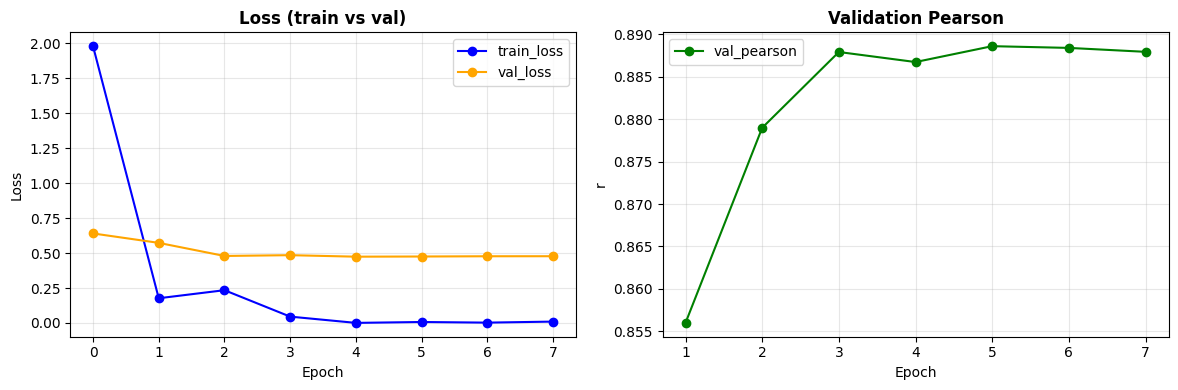

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_pearson did not improve in the last 3 records. Best score: 0.889. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 7, global step 2880: 'val_pearson' was not in top 1


In [ ]:
ds = load_dataset("mteb/stsbenchmark-sts", "default")

tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
data_module_cross_bert = CrossEncoderDataModule(
    train_dataset=ds["train"],
    val_dataset=ds["validation"],
    tokenizer=tokenizer_bert,
    batch_size=16
)

model_cross_bert = CrossEncoderSTS("bert-base-uncased", lr=2e-5)
cross_bert_logger = LiveMetricsSTSCallback()

checkpoint_callback_cross_bert = ModelCheckpoint(
    dirpath="/content/checkpoints/cross-bert",
    monitor="val_pearson",
    mode="max",
    save_top_k=1,
    filename="best-cross-bert-{epoch:02d}-{val_pearson:.4f}",
    verbose=True,
    save_weights_only=False,
)

early_stop_cross_bert = EarlyStopping(
    monitor="val_pearson",
    patience=3,
    mode="max",
    verbose=True
)

trainer_cross_bert = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    callbacks=[cross_bert_logger, checkpoint_callback_cross_bert, early_stop_cross_bert]
)

trainer_cross_bert.fit(model_cross_bert, datamodule=data_module_cross_bert)

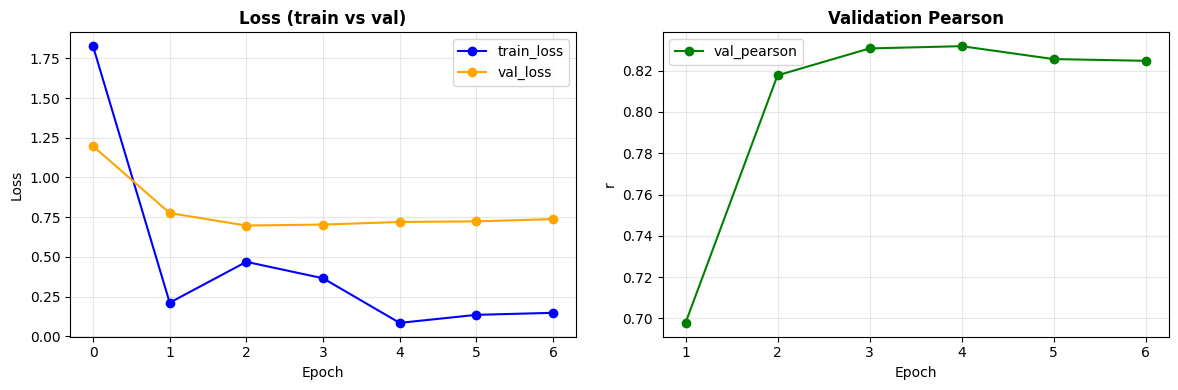

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_pearson did not improve in the last 3 records. Best score: 0.832. Signaling Trainer to stop.
INFO:pytorch_lightning.utilities.rank_zero:Epoch 6, global step 2520: 'val_pearson' was not in top 1


In [ ]:
ds = load_dataset("mteb/stsbenchmark-sts", "default")

tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")
tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token

data_module_cross_gpt2 = CrossEncoderDataModule(
    train_dataset=ds["train"],
    val_dataset=ds["validation"],
    tokenizer=tokenizer_gpt2,
    batch_size=16
)

model_cross_gpt2 = CrossEncoderSTS("gpt2", lr=1e-5)
cross_gpt2_logger = LiveMetricsSTSCallback()

checkpoint_callback_cross_gpt2 = ModelCheckpoint(
    dirpath="/content/checkpoints/cross-gpt2",
    monitor="val_pearson",
    mode="max",
    save_top_k=1,
    filename="best-cross-gpt2-{epoch:02d}-{val_pearson:.4f}",
    verbose=True,
    save_weights_only=False,
)

early_stop_cross_gpt2 = EarlyStopping(
    monitor="val_pearson",
    patience=3,
    mode="max",
    verbose=True
)

trainer_cross_gpt2 = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    callbacks=[cross_gpt2_logger, checkpoint_callback_cross_gpt2, early_stop_cross_gpt2]
)

trainer_cross_gpt2.fit(model_cross_gpt2, datamodule=data_module_cross_gpt2)

# Final Evaluation of Pearson Correlation


In [ ]:
def predict_similarity_cross(model, tokenizer, sentence1, sentence2, max_length=256, device=None):
    """
    Differences from predict_similarity (Bi-Encoder):
        The Cross-Encoder receives the two sentences concatenated as a single
        input, just as it does during training. It returns a direct score in
        [0, 5] without normalization.

    Clamp:
        The Cross-Encoder's linear layer has no activation constraint, so it can
        predict values outside the [0, 5] range for examples far from the
        training distribution. torch.clamp is applied to ensure the returned
        score always remains inside the valid range. In the Bi-Encoder this is
        not necessary because cosine similarity returns values in [-1, 1].
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    enc = tokenizer(
        sentence1, sentence2,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    token_type_ids = enc["token_type_ids"].to(device) if "token_type_ids" in enc else None

    with torch.no_grad():
        score = model(input_ids, attention_mask, token_type_ids)
    score = torch.clamp(score, min=0.0, max=5.0)
    return score.item()

In [ ]:

# -- Load baseline model ------------------------------------------
baseline_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def predict_similarity_baseline(model, sentence1, sentence2):
    """
    Baseline using sentence-transformers/all-MiniLM-L6-v2.
    Returns a score in [0, 5] for comparison with the fine-tuned models.
    """
    emb1 = model.encode(sentence1, convert_to_tensor=True)
    emb2 = model.encode(sentence2, convert_to_tensor=True)
    cosine = util.cos_sim(emb1, emb2).item()  # [-1, 1]
    score = (cosine + 1) / 2 * 5              # → [0, 5]
    return score

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# ── Pearson r del baseline en test set ─────────────────────────
test_set = list(ds["test"])

preds_baseline, labels_gt = [], []
for item in test_set:
    score = predict_similarity_baseline(
        baseline_model, item["sentence1"], item["sentence2"]
    )
    preds_baseline.append(score)
    labels_gt.append(float(item["score"]))

r_baseline, _ = pearsonr(preds_baseline, labels_gt)
print(f"Baseline (all-MiniLM-L6-v2) — Pearson r: {r_baseline:.4f}")

Baseline (all-MiniLM-L6-v2) — Pearson r: 0.8274


In [ ]:
# ================================================================
# Load models and tokenizers
# ================================================================

def load_model(model_cls, checkpoint_path, model_name, pad_eos=False):
    """Load a model from a checkpoint and prepare it for inference."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if pad_eos:
        tokenizer.pad_token = tokenizer.eos_token
    model = model_cls.load_from_checkpoint(checkpoint_path, model_name=model_name)
    model.eval()
    model.to("cuda")
    return model, tokenizer

best_bi_bert = trainer_bi_bert.checkpoint_callback.best_model_path
best_bi_gpt2 = trainer_bi_gpt2.checkpoint_callback.best_model_path
best_cross_bert = trainer_cross_bert.checkpoint_callback.best_model_path
best_cross_gpt2 = trainer_cross_gpt2.checkpoint_callback.best_model_path

model_bert, tokenizer_bert = load_model(
    BiEncoderSTS,
    best_bi_bert,
    "bert-base-uncased"
)

model_gpt2, tokenizer_gpt2 = load_model(
    BiEncoderSTS,
    best_bi_gpt2,
    "gpt2",
    pad_eos=True
)

model_cross_bert, tokenizer_cross_bert = load_model(
    CrossEncoderSTS,
    best_cross_bert,
    "bert-base-uncased"
)

model_cross_gpt2, tokenizer_cross_gpt2 = load_model(
    CrossEncoderSTS,
    best_cross_gpt2,
    "gpt2",
    pad_eos=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ================================================================
# EVALUACIÓN FINAL: Correlación de Pearson en Test Set
# ================================================================

def evaluate_pearson(model, tokenizer, dataset, predict_fn, device="cuda", max_length=128):
    """Compute Pearson r on the test set."""
    preds, labels = [], []
    for item in dataset:
        score = predict_fn(model, tokenizer, item["sentence1"], item["sentence2"],
                          max_length=max_length, device=device)
        preds.append(score)
        labels.append(item["score"])
    r, _ = pearsonr(preds, labels)
    return r

model_bert.to("cuda")
model_bi_gpt2.to("cuda")
model_cross_bert.to("cuda")
model_cross_gpt2.to("cuda")
test_set = list(ds["test"])

r_bi_bert    = evaluate_pearson(model_bert,       tokenizer_bert,        test_set, predict_similarity,       max_length=128)
r_bi_gpt2    = evaluate_pearson(model_bi_gpt2,    tokenizer_gpt2,        test_set, predict_similarity,       max_length=128)
r_cross_bert = evaluate_pearson(model_cross_bert, tokenizer_cross_bert,  test_set, predict_similarity_cross, max_length=256)
r_cross_gpt2 = evaluate_pearson(model_cross_gpt2, tokenizer_cross_gpt2, test_set, predict_similarity_cross, max_length=256)

# Results table
results = pd.DataFrame({
    "Model":       ["Baseline (all-MiniLM-L6-v2)", "Bi-Encoder BERT", "Bi-Encoder GPT-2",
                     "Cross-Encoder BERT", "Cross-Encoder GPT-2"],
    "Architecture": ["Bi-Encoder",  "Bi-Encoder", "Bi-Encoder", "Cross-Encoder", "Cross-Encoder"],
    "Backbone":     ["MiniLM",      "BERT",       "GPT-2",      "BERT",          "GPT-2"],
    "Pearson r":    [r_baseline,    r_bi_bert,    r_bi_gpt2,    r_cross_bert,    r_cross_gpt2]
}).sort_values("Pearson r", ascending=False).reset_index(drop=True)


results = results.sort_values("Pearson r", ascending=False).reset_index(drop=True)
results["Pearson r"] = results["Pearson r"].map("{:.4f}".format)
results.index += 1

print("\n Results on the STSBenchmark Test Set")
print("=" * 55)
print(results.to_string())
print("=" * 55)
print(f"Best model: {results.iloc[0]['Modelo']} (r = {results.iloc[0]['Pearson r']})")


 Resultados en STSBenchmark Test Set
                        Modelo   Arquitectura Backbone Pearson r
1           Cross-Encoder BERT  Cross-Encoder     BERT    0.8410
2  Baseline (all-MiniLM-L6-v2)     Bi-Encoder   MiniLM    0.8274
3          Cross-Encoder GPT-2  Cross-Encoder    GPT-2    0.8086
4              Bi-Encoder BERT     Bi-Encoder     BERT    0.6438
5             Bi-Encoder GPT-2     Bi-Encoder    GPT-2    0.3517
Mejor modelo: Cross-Encoder BERT (r = 0.8410)


In [ ]:
# ================================================================
# Linear calibration of the BERT Cross-Encoder
# ================================================================
val_set = list(ds["validation"])

val_preds_cross_bert = []
val_labels_gt = []

for item in val_set:
    score = predict_similarity_cross(
        model_cross_bert, tokenizer_cross_bert,
        item["sentence1"], item["sentence2"], device="cuda"
    )
    val_preds_cross_bert.append(score)
    val_labels_gt.append(float(item["score"]))

slope, intercept, _, _, _ = linregress(val_preds_cross_bert, val_labels_gt)
print(f"slope: {slope:.4f}, intercept: {intercept:.4f}")


def predict_similarity_cross_calibrated(model, tokenizer, sentence1, sentence2,
                                         slope, intercept, max_length=256, device=None):
    """
    Calibrate the BERT Cross-Encoder output using a linear regression fitted on
    the validation set. The model's linear layer has no activation constraint, so
    it tends to predict compressed scores in the middle range [0, 3] without
    reaching the extremes of the [0, 5] scale. The linear adjustment (slope,
    intercept) corrects this compression by scaling predictions so they cover the
    full range, without affecting Pearson r, which is invariant to linear
    transformations.
    """
    score_raw = predict_similarity_cross(model, tokenizer, sentence1, sentence2,
                                          max_length=max_length, device=device)
    calibrated_score = slope * score_raw + intercept
    return float(np.clip(calibrated_score, 0, 5))

slope: 0.9934, intercept: 0.0414


In [ ]:
# ================================================================
# DEMO: 6 sentence pairs with expected similarity from 0 to 5
# Comparison: BERT Cross-Encoder vs Baseline (all-MiniLM-L6-v2)
# ================================================================

pairs_demo = [
    {
        "s1": "The astronaut floated in zero gravity.",
        "s2": "She baked a chocolate cake for the party.",
        "expected": 0,
        "reason": "Temas completamente distintos, sin ninguna relación semántica."
    },
    {
        "s1": "The politician gave a speech at the conference.",
        "s2": "A child is playing with a red balloon.",
        "expected": 1,
        "reason": "Ambas describen una acción humana pero en contextos totalmente distintos."
    },
    {
        "s1": "The student is reading a book in the library.",
        "s2": "A young woman is studying at her desk.",
        "expected": 2,
        "reason": "Contexto académico compartido pero acciones y sujetos distintos."
    },
    {
        "s1": "A small dog is chasing a ball in the park.",
        "s2": "A puppy is running after a toy outside.",
        "expected": 3,
        "reason": "Misma idea general con variación en sujeto, objeto y lugar."
    },
    {
        "s1": "A man is playing the guitar in a concert.",
        "s2": "A musician is performing with a guitar.",
        "expected": 4,
        "reason": "Misma acción y objeto, pequeñas diferencias léxicas."
    },
    {
        "s1": "Two people are shaking hands.",
        "s2": "Two persons are sharing hand shakes.",
        "expected": 5,
        "reason": "Significado idéntico, solo paráfrasis."
    },
]

print("=" * 70)
print("  Demo: 6 similarity pairs from 0 to 5")
print("  Cross-Encoder BERT vs Baseline (all-MiniLM-L6-v2)")
print("  Sentences not included in STSBenchmark")
print("=" * 70)

for pair in pairs_demo:
    score_cross = predict_similarity_cross_calibrated(
        model_cross_bert, tokenizer_cross_bert,
        pair["s1"], pair["s2"],
        slope=slope, intercept=intercept, device="cuda"
    )
    score_baseline = predict_similarity_baseline(
        baseline_model, pair["s1"], pair["s2"]
    )
    print(f"  Expected similarity  : {pair['expected']} / 5")
    print(f"  S1: {pair['s1']}")
    print(f"  S2: {pair['s2']}")
    print(f"  Reason: {pair['reason']}")
    print(f"  Cross-Encoder BERT    : {score_cross:.2f} / 5.00")
    print(f"  Baseline (MiniLM)     : {score_baseline:.2f} / 5.00")
    print("-" * 70)

  Demostracion: 6 pares de similitud 0 a 5
  Cross-Encoder BERT vs Baseline (all-MiniLM-L6-v2)
  Frases no contenidas en el STSBenchmark
  Similitud esperada    : 0 / 5
  S1: The astronaut floated in zero gravity.
  S2: She baked a chocolate cake for the party.
  Razon: Temas completamente distintos, sin ninguna relación semántica.
  Cross-Encoder BERT    : 0.39 / 5.00
  Baseline (MiniLM)     : 2.58 / 5.00
----------------------------------------------------------------------
  Similitud esperada    : 1 / 5
  S1: The politician gave a speech at the conference.
  S2: A child is playing with a red balloon.
  Razon: Ambas describen una acción humana pero en contextos totalmente distintos.
  Cross-Encoder BERT    : 0.32 / 5.00
  Baseline (MiniLM)     : 2.39 / 5.00
----------------------------------------------------------------------
  Similitud esperada    : 2 / 5
  S1: The student is reading a book in the library.
  S2: A young woman is studying at her desk.
  Razon: Contexto académico c

The model preserves the relative similarity ordering between sentence pairs, which is consistent with the Pearson correlation coefficient (r = 0.8410) obtained on the test set.

However, the absolute scores tend to concentrate in the middle range. This is likely due to the use of MSELoss during training, together with an imbalanced score distribution where extreme values such as 5 are underrepresented.

When comparing predictions, the BERT-based cross-encoder produces more coherent results than the baseline in cases with low or no semantic relationship. For example, in pairs with expected labels of 0/5 and 1/5, the baseline overestimates similarity by assigning values close to 3 even though the sentences are unrelated.

On the other hand, when similarity is high (for example, 4/5), the baseline can outperform the cross-encoder. Overall, the model is strongest at detecting the absence of semantic relatedness, but it is more conservative when assigning high scores and requires very clear similarity to do so.

It is also worth noting that sentence-pair comparison was tested with the GPT-2 bi-encoder model. Although it achieved a lower Pearson coefficient, its behavior was closer to the baseline.
